## (1) In the lecture we discussed two built-in list predicates, `member` and `append` (which we referred to as `concat`). Write and run a Prolog query for each of the following questions, and record the answers.

### (a) Is 3 a member of the list `[a,b,c,1,2,3]`?

It outputs the following:
```
?- member(3, [a,b,c,1,2,3]).
true.
```

### (b) What are the names of the people in the following list: `[person(socrates), cat(twinkles), point(5,2), person(aristotle), person(sally), god(zeus)]`?

You can find out by querying the person members of the list:
```
?- member(person(Who), [person(socrates), cat(twinkles), point(5,2),
person(aristotle), person(sally), god(zeus)]).
Who = socrates ;
Who = aristotle ;
Who = sally ;
false.
```

### c) Find all the numbers in the following list that are smaller than 0: `[9, 2, 6, -5, -3, -9, 8, 3]`?

You can assign the member to a variable `N` and put it in conjunction with `N < 0`:
```
?- member(N, [9, 2, 6, -5, -3, -9, 8, 3]), N < 0.
N = -5 ;
N = -3 ;
N = -9 ;
false.
```

### (d) Find all elements of the list `[a,b,c,d,e]` that are not members of the list `[a,c,e,f,z]`.
*Hint*: use `member` twice, and the built-in `not/1` predicate.

With the hint used it gives:
```
?- member(X, [a,b,c,d,e]), not(member(X, [a,c,e,f,z])).
X = b ;
X = d ;
false.
```

### (e) What is the result of appending (concatenating) the following two lists together: `[a,d,g]` and `[4,7,9]`?

Using the syntax shown here https://www.swi-prolog.org/pldoc/man?predicate=append%2f3.
```
?- append([a,d,g], [4,7,9], X).
X = [a, d, g, 4, 7, 9].
```

### (f) What is the last element of the following list: `[person(socrates), cat(twinkles), point(5,2), person(aristotle), person(sally), god(zeus)]`?

You can use the Last keyword:
```
?- append(_, [Last], [person(socrates), cat(twinkles), point(5,2), pe
rson(aristotle), person(sally), god(zeus)]).
Last = god(zeus) .
```

## (2) *It was a dark and stormy night ...* In our first lecture on Prolog we were searching through a splendid palace looking for a telephone. Here is the floorplan:
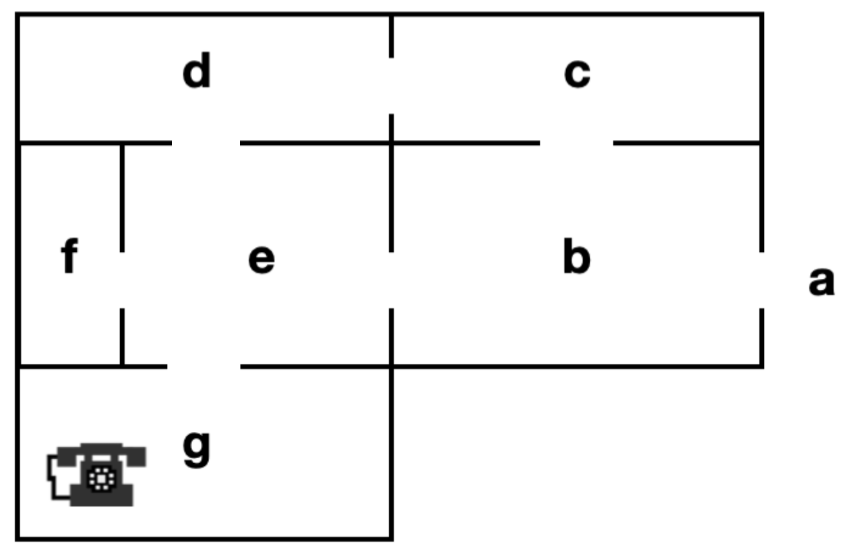
We started outside at location a and needed to search through the house to get to the telephone in room *g*. We represent adjacent rooms with facts `adjacent/2` such that every pair of rooms has *at most* one such fact, e.g.:
```pl
adjacent(a,b).
adjacent(b,c).
adjacent(b,e).
...
```

### (a) Start a new Prolog file, and complete the above facts to represent the floorplan in the image. Remember that at most only one fact should be given for each pair of rooms.

The floorplan is represented as follows:
```pl
adjacent(a,b).
adjacent(b,c).
adjacent(b,e).
adjacent(c,d).
adjacent(d,e).
adjacent(e,d).
adjacent(e,f).
adjacent(e,g).
```

### (b) Include a fact `has_phone/1` that represents the room that the phone is in.

Since room g has the phone it will be
```pl
has_phone(g).
```

### (c) In the lecture we implemented the predicate `can_reach_phone/1` recursively. The logic was that we can reach the phone from a given `Room` if (a) the phone is in `Room`, or (b) we can reach the phone from a room that is adjacent to `Room`:
```pl
can_reach_phone(Room) :-
    has_phone(Room).

can_reach_phone(Room) :-
    adjacent(Room, Next),
    can_reach_phone(Next).
```

But we didn’t keep track of the rooms we visited so far, which meant we could get trapped in infinite cycles.

Include a second argument in the predicate `can_reach_phone/2` that is a list of rooms we’ve visited so far. E.g. to use this query starting from location a we make the call with the empty list:
```
?- can_reach_phone(a, []).
```

```pl
can_reach_phone(Room, Visited) :-
    has_phone(Room).
can_reach_phone(Room, Visited) :-
    adjacent(Room, Next),
    can_reach_phone(Next, Visited).
```

### (d) Change the predicate definition of `can_reach_phone/2` so that we only visit an adjacent room if we did not visit it before.

```pl
can_reach_phone(Room, Visited) :-
    adjacent(Room, Next),
    not(member(Next, Visited)),
    append(Visited, [Next], NewVisited),
    can_reach_phone(Next, NewVisited);
```

### (e) Recall that our `adjacent/2` facts only represent one direction (e.g. location *a* is adjacent to room *b)*. Change the definition of `can_reach_phone/2` so that we can visit rooms going in either direction. *Hint:* in Prolog “;” is logical *or* (disjunction), e.g. try this as a query, and press “spacebar” to enumerate all solutions:
```pl
?- (X = 1 ; X = 2), Y = 3.
```

```pl
can_reach_phone(Room, Visited) :-
    (adjacent(Room, Next) ; adjacent(Next, Room) ),
    not(member(Next, Visited)),
    append(Visited, [Next], NewVisited),
    can_reach_phone(Next, NewVisited).
```

### (f) *Optional:* Use the built in predicate `format/2` like we did in lectures to print out the current room, and the path so far, at every step.

```pl
can_reach_phone(Room, Visited) :-
    has_phone(Room),
    format("Ring ring from room ~w~n", [Room]).

can_reach_phone(Room, Visited) :-
    format("Visiting room ~w~n", [Room]),
    (adjacent(Room, Next) ; adjacent(Next, Room) ),
    not(member(Next, Visited)),
    append(Visited, [Next], NewVisited),
    can_reach_phone(Next, NewVisited).
```

```
?- can_reach_phone(a, []).
Visiting room a
Visiting room b
Visiting room c
Visiting room d
Visiting room e
Visiting room f
Ring ring from room g
true .
```

## (3) In a previous lecture we discussed the reverse function that reverses the elements of a list:
```pl
reverse xs = reverse_acc xs []
reverse_acc [] ys = ys
reverse_acc (x::xs) ys = reverse_acc xs (x::ys)
```

### (a) Implement the predicates `reverse/2` and `reverse_acc/3` in Prolog, according to the above three equations

The predicates can be implemented as such
```pl
reverse(Xs, Ys) :- reverse_acc(Xs, [], Ys).
reverse_acc([], Acc, Acc).
reverse_acc([X|Xs], Acc, Ys) :- reverse_acc(Xs, [X|Acc], Ys).
```

### (b) Demonstrate your predicate with 2-3 queries where a list gets reversed

```
?- reverse([a,b,c,d],A).
A = [d, c, b, a].

?- reverse([socrates, aristotle, zeus], A).
A = [zeus, aristotle, socrates].

?- reverse([], A).
A = [].
```